# PROYECTO FINAL

Cual sera la cantidad de ventas de supplies en el mes de Mayo de 2026

# Obtenemos Datos con API

In [1]:
import os

# El nombre de usuario es el que aparece en tu URL de Kaggle (ej: 'juanperez')
os.environ['KAGGLE_USERNAME'] = "danieldelgado23"

# Aquí pega el código largo (Token) que te generó la página de tu imagen
os.environ['KAGGLE_KEY'] = "KGAT_d569c08c514f70167820700b42051e32"

In [2]:
import kaggle

# Definimos el dataset y la ruta donde lo quieres guardar
dataset = 'shekpaul/global-superstore'
ruta = '../data/raw/'

# Descarga y descomprime
kaggle.api.dataset_download_files(dataset, path=ruta, unzip=True)

print("¡Listo! El archivo ya debe estar en tu carpeta ../data/raw/")

Dataset URL: https://www.kaggle.com/datasets/shekpaul/global-superstore
¡Listo! El archivo ya debe estar en tu carpeta ../data/raw/


In [3]:
import pandas as pd

# 1. Ruta corregida (Saliendo de 'src')
file_path = '../data/raw/Global Superstore.xls'

# 2. Intentamos leer como Excel real (necesitas instalar: pip install xlrd)
try:
    df = pd.read_excel(file_path)
    print("¡Cargado como Excel!")
except:
    # 3. Si falla, es que es un HTML disfrazado
    try:
        tablas = pd.read_html(file_path)
        df = tablas[0]
        print("¡Cargado como Tabla HTML!")
    except Exception as e:
        print(f"Sigue fallando. Error: {e}")

# Si logramos cargar algo, limpiamos nombres de columnas
if 'df' in locals():
    df.columns = [col.strip().replace(' ', '_').lower() for col in df.columns]
    display(df.head())

¡Cargado como Excel!


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


# AHORA SI!

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row_id          51290 non-null  int64         
 1   order_id        51290 non-null  str           
 2   order_date      51290 non-null  datetime64[us]
 3   ship_date       51290 non-null  datetime64[us]
 4   ship_mode       51290 non-null  str           
 5   customer_id     51290 non-null  str           
 6   customer_name   51290 non-null  str           
 7   segment         51290 non-null  str           
 8   city            51290 non-null  str           
 9   state           51290 non-null  str           
 10  country         51290 non-null  str           
 11  postal_code     9994 non-null   float64       
 12  market          51290 non-null  str           
 13  region          51290 non-null  str           
 14  product_id      51290 non-null  str           
 15  category     

- Tenemos un data set de 24 columnas y 51.290 filas
- De un principio sacaremos variables que no aportan nada al modelo

In [5]:
df = df.drop(['row_id','postal_code','order_id','customer_id','customer_name','product_id','product_name'], axis = 1)
df.head()

,order_date,ship_date,ship_mode,segment,city,state,country,market,region,category,sub-category,sales,quantity,discount,profit,shipping_cost,order_priority
0,2012-07-31,2012-07-31,Same Day,Consumer,New York City,New York,United States,US,East,Technology,Accessories,2309.650,7,0.0,762.1845,933.57,Critical
1,2013-02-05,2013-02-07,Second Class,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,3709.395,9,0.1,-288.7650,923.63,Critical
2,2013-10-17,2013-10-18,First Class,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,5175.171,9,0.1,919.9710,915.49,Medium
3,2013-01-28,2013-01-30,First Class,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,2892.510,5,0.1,-96.5400,910.16,Medium
4,2013-11-05,2013-11-06,Same Day,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,2832.960,8,0.0,311.5200,903.04,Critical


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_date      51290 non-null  datetime64[us]
 1   ship_date       51290 non-null  datetime64[us]
 2   ship_mode       51290 non-null  str           
 3   segment         51290 non-null  str           
 4   city            51290 non-null  str           
 5   state           51290 non-null  str           
 6   country         51290 non-null  str           
 7   market          51290 non-null  str           
 8   region          51290 non-null  str           
 9   category        51290 non-null  str           
 10  sub-category    51290 non-null  str           
 11  sales           51290 non-null  float64       
 12  quantity        51290 non-null  int64         
 13  discount        51290 non-null  float64       
 14  profit          51290 non-null  float64       
 15  shipping_cost

# INICIAMOS CON EL EDA

In [7]:
# Creo una columna del mes del pedido

df['order_month'] = df['order_date'].dt.strftime('%Y-%m')
df = df.drop(['order_date','ship_date'], axis = 1)
df.head()

,ship_mode,segment,city,state,country,market,region,category,sub-category,sales,quantity,discount,profit,shipping_cost,order_priority,order_month
0,Same Day,Consumer,New York City,New York,United States,US,East,Technology,Accessories,2309.650,7,0.0,762.1845,933.57,Critical,2012-07
1,Second Class,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,3709.395,9,0.1,-288.7650,923.63,Critical,2013-02
2,First Class,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,5175.171,9,0.1,919.9710,915.49,Medium,2013-10
3,First Class,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,2892.510,5,0.1,-96.5400,910.16,Medium,2013-01
4,Same Day,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,2832.960,8,0.0,311.5200,903.04,Critical,2013-11


In [8]:
# Elimino Duplicados

df.drop('order_month',axis=1).drop_duplicates().sum()
df = df.sort_values(by='order_month')
df.info()

<class 'pandas.DataFrame'>
Index: 51290 entries, 30643 to 44106
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ship_mode       51290 non-null  str    
 1   segment         51290 non-null  str    
 2   city            51290 non-null  str    
 3   state           51290 non-null  str    
 4   country         51290 non-null  str    
 5   market          51290 non-null  str    
 6   region          51290 non-null  str    
 7   category        51290 non-null  str    
 8   sub-category    51290 non-null  str    
 9   sales           51290 non-null  float64
 10  quantity        51290 non-null  int64  
 11  discount        51290 non-null  float64
 12  profit          51290 non-null  float64
 13  shipping_cost   51290 non-null  float64
 14  order_priority  51290 non-null  str    
 15  order_month     51290 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 6.7 MB


- No hay duplicados ni valores nulos

In [9]:
df = df[df['category'] == 'Office Supplies']
df.info()

<class 'pandas.DataFrame'>
Index: 31273 entries, 30643 to 44106
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ship_mode       31273 non-null  str    
 1   segment         31273 non-null  str    
 2   city            31273 non-null  str    
 3   state           31273 non-null  str    
 4   country         31273 non-null  str    
 5   market          31273 non-null  str    
 6   region          31273 non-null  str    
 7   category        31273 non-null  str    
 8   sub-category    31273 non-null  str    
 9   sales           31273 non-null  float64
 10  quantity        31273 non-null  int64  
 11  discount        31273 non-null  float64
 12  profit          31273 non-null  float64
 13  shipping_cost   31273 non-null  float64
 14  order_priority  31273 non-null  str    
 15  order_month     31273 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 4.1 MB


# Analisis univariante

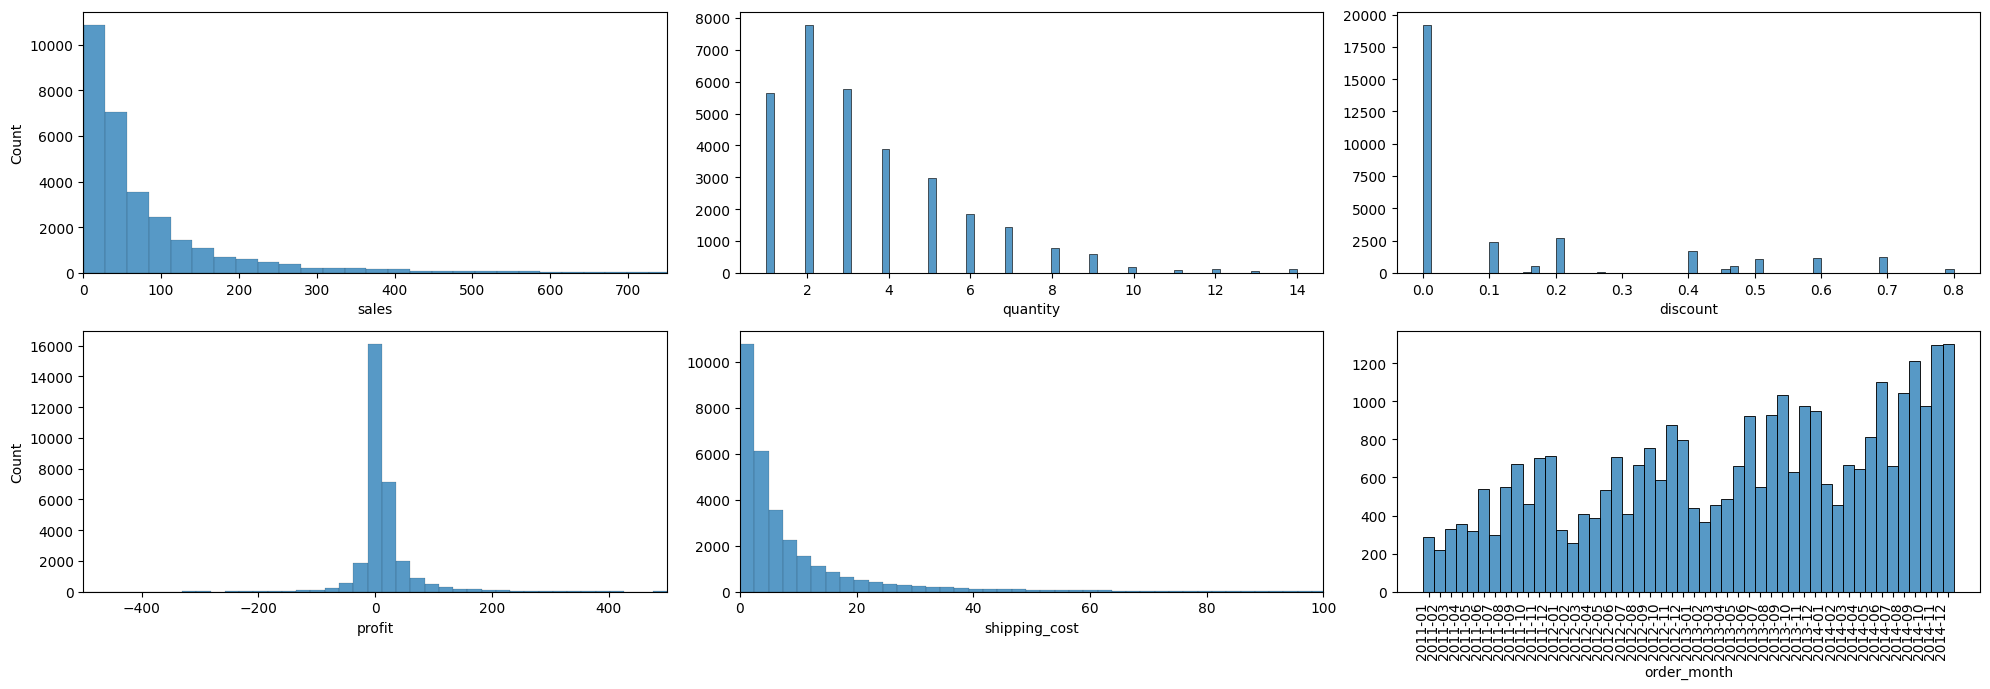

In [10]:
# Variables Numericas

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2,3,figsize = (20,7))

sns.histplot(ax = ax[0,0],data= df, x = 'sales').set(xlim = (0,750))
sns.histplot(ax = ax[0,1],data= df, x = 'quantity').set(ylabel = None)
sns.histplot(ax = ax[0,2],data= df, x = 'discount').set(ylabel = None)
sns.histplot(ax = ax[1,0],data= df, x = 'profit').set(xlim = (-500,500))
sns.histplot(ax = ax[1,1],data= df, x = 'shipping_cost').set(ylabel = None,xlim = (0,100))
sns.histplot(ax = ax[1,2],data= df, x = 'order_month').set(ylabel = None)

plt.setp(ax[1,2].get_xticklabels(), rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [11]:
df[df['sales'] <= 1]

,ship_mode,segment,city,state,country,market,region,category,sub-category,sales,quantity,discount,profit,shipping_cost,order_priority,order_month
51138,Same Day,Consumer,Philadelphia,Pennsylvania,United States,US,East,Office Supplies,Binders,0.852,1,0.7,-0.5964,0.10,High,2011-03
51166,Same Day,Corporate,Mesquite,Texas,United States,US,Central,Office Supplies,Binders,0.876,1,0.8,-1.4016,0.09,High,2011-09
51258,Standard Class,Corporate,Huntsville,Texas,United States,US,Central,Office Supplies,Binders,0.898,1,0.8,-1.5715,0.04,Medium,2011-10
51035,First Class,Consumer,Houston,Texas,United States,US,Central,Office Supplies,Binders,0.984,2,0.8,-1.4760,0.14,High,2012-06
51223,Standard Class,Corporate,Chicago,Illinois,United States,US,Central,Office Supplies,Binders,0.836,1,0.8,-1.3376,0.06,Medium,2013-06
51194,Same Day,Corporate,Waco,Texas,United States,US,Central,Office Supplies,Binders,0.556,1,0.8,-0.9452,0.08,Medium,2014-03
51286,Standard Class,Consumer,Houston,Texas,United States,US,Central,Office Supplies,Appliances,0.444,1,0.8,-1.1100,0.01,Medium,2014-06


In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 31273 entries, 30643 to 44106
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ship_mode       31273 non-null  str    
 1   segment         31273 non-null  str    
 2   city            31273 non-null  str    
 3   state           31273 non-null  str    
 4   country         31273 non-null  str    
 5   market          31273 non-null  str    
 6   region          31273 non-null  str    
 7   category        31273 non-null  str    
 8   sub-category    31273 non-null  str    
 9   sales           31273 non-null  float64
 10  quantity        31273 non-null  int64  
 11  discount        31273 non-null  float64
 12  profit          31273 non-null  float64
 13  shipping_cost   31273 non-null  float64
 14  order_priority  31273 non-null  str    
 15  order_month     31273 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 4.1 MB


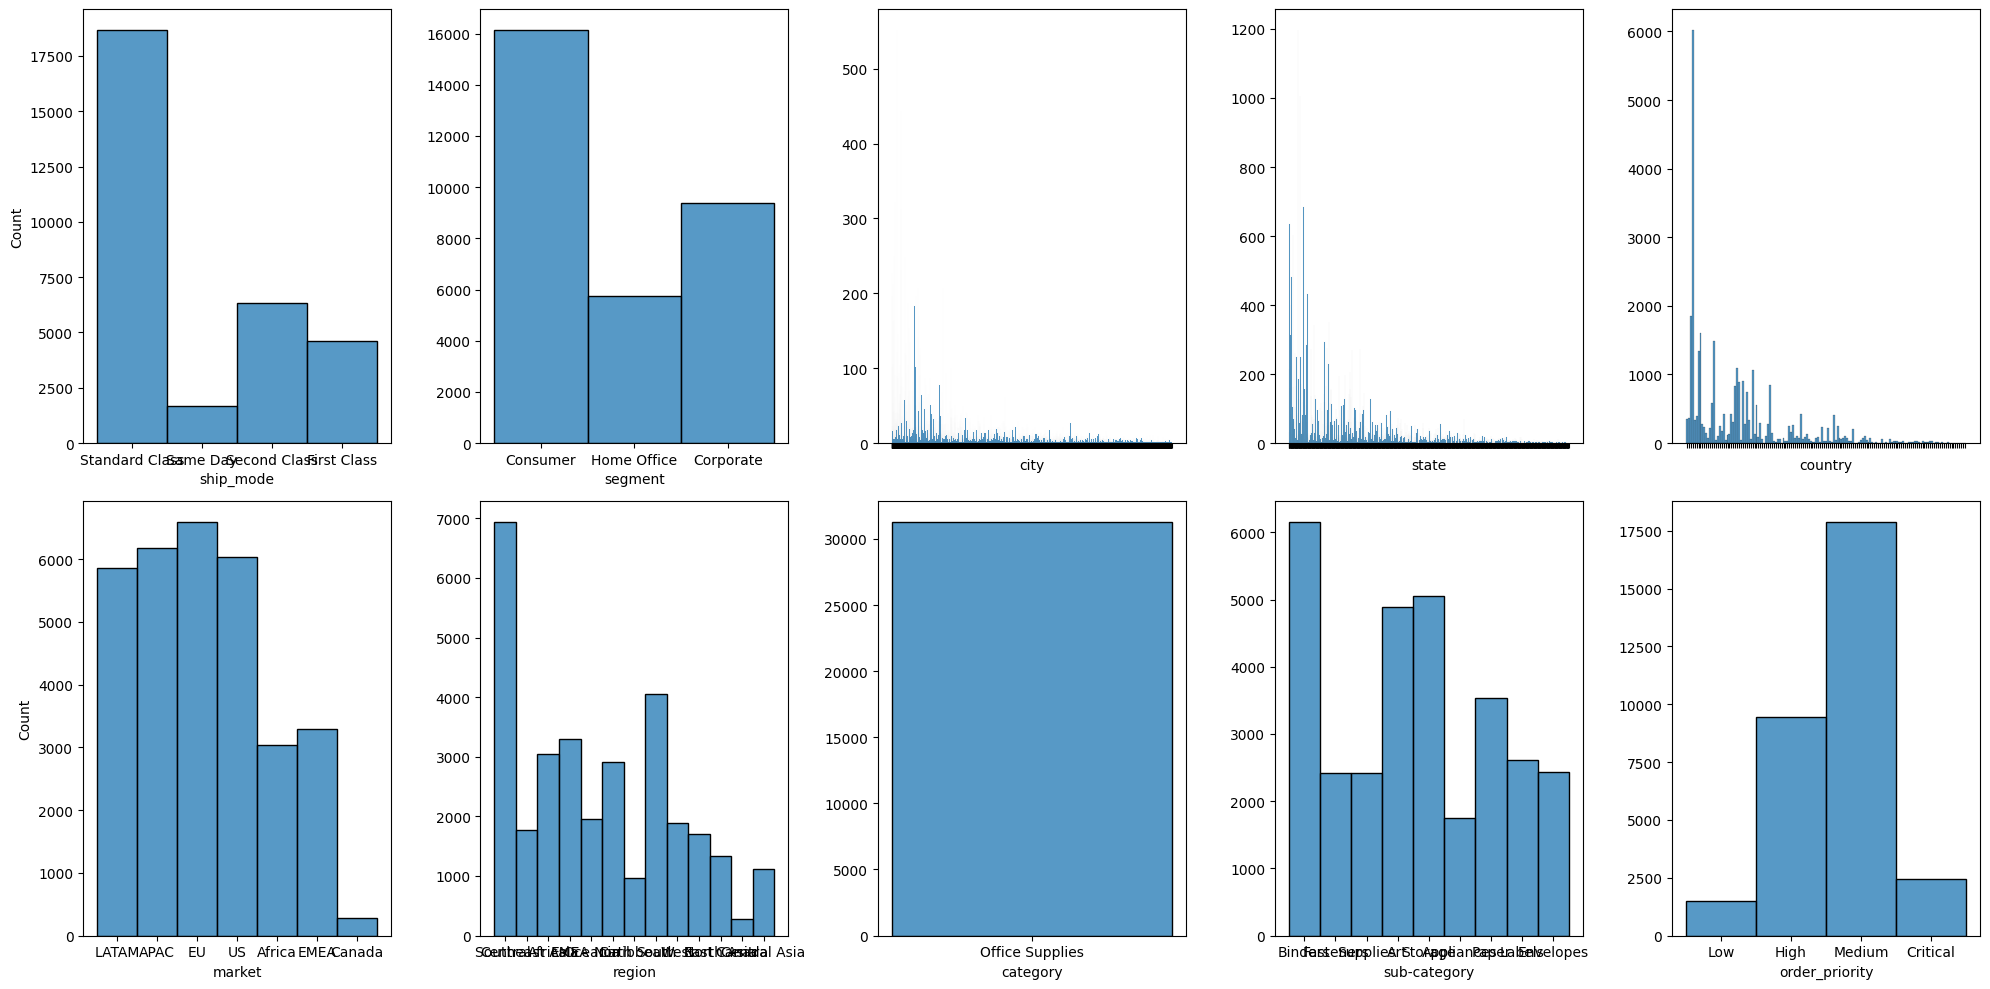

In [13]:
# Variables Categoricas
fig, ax = plt.subplots(2,5,figsize = (20,10))

sns.histplot(ax = ax[0,0],data= df, x = 'ship_mode')
sns.histplot(ax = ax[0,1],data= df, x = 'segment').set(ylabel = None)
sns.histplot(ax = ax[0,2],data= df, x = 'city').set(ylabel = None)
ax[0,2].set_xticklabels([])
sns.histplot(ax = ax[0,3],data= df, x = 'state').set(ylabel = None)
ax[0,3].set_xticklabels([])
sns.histplot(ax = ax[0,4],data= df, x = 'country').set(ylabel = None)
ax[0,4].set_xticklabels([])
sns.histplot(ax = ax[1,0],data= df, x = 'market')
sns.histplot(ax = ax[1,1],data= df, x = 'region').set(ylabel = None)
sns.histplot(ax = ax[1,2],data= df, x = 'category').set(ylabel = None)
sns.histplot(ax = ax[1,3],data= df, x = 'sub-category').set(ylabel = None)
sns.histplot(ax = ax[1,4],data= df, x = 'order_priority').set(ylabel = None)


plt.tight_layout()
plt.show()

- City, State y Country se comportan de la misma forma, y dan la misma informacion. Nos quedaremos con market 

In [14]:
df = df.drop(['city','state','country'], axis = 1)
df.head()

,ship_mode,segment,market,region,category,sub-category,sales,quantity,discount,profit,shipping_cost,order_priority,order_month
30643,Standard Class,Consumer,LATAM,Central,Office Supplies,Binders,60.9600,8,0.00,28.6400,5.216,Low,2011-01
29861,Standard Class,Home Office,APAC,Southeast Asia,Office Supplies,Fasteners,51.6285,7,0.45,4.5885,5.550,High,2011-01
29871,Same Day,Consumer,LATAM,Central,Office Supplies,Supplies,47.9600,2,0.00,15.8000,5.546,Medium,2011-01
16593,Standard Class,Consumer,EU,Central,Office Supplies,Art,177.6600,7,0.00,58.5900,16.940,Medium,2011-01
24712,Standard Class,Consumer,US,Central,Office Supplies,Storage,66.5800,2,0.00,15.9792,8.400,Medium,2011-01


# Analisis Multivariante

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 31273 entries, 30643 to 44106
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ship_mode       31273 non-null  str    
 1   segment         31273 non-null  str    
 2   market          31273 non-null  str    
 3   region          31273 non-null  str    
 4   category        31273 non-null  str    
 5   sub-category    31273 non-null  str    
 6   sales           31273 non-null  float64
 7   quantity        31273 non-null  int64  
 8   discount        31273 non-null  float64
 9   profit          31273 non-null  float64
 10  shipping_cost   31273 non-null  float64
 11  order_priority  31273 non-null  str    
 12  order_month     31273 non-null  str    
dtypes: float64(4), int64(1), str(8)
memory usage: 3.3 MB


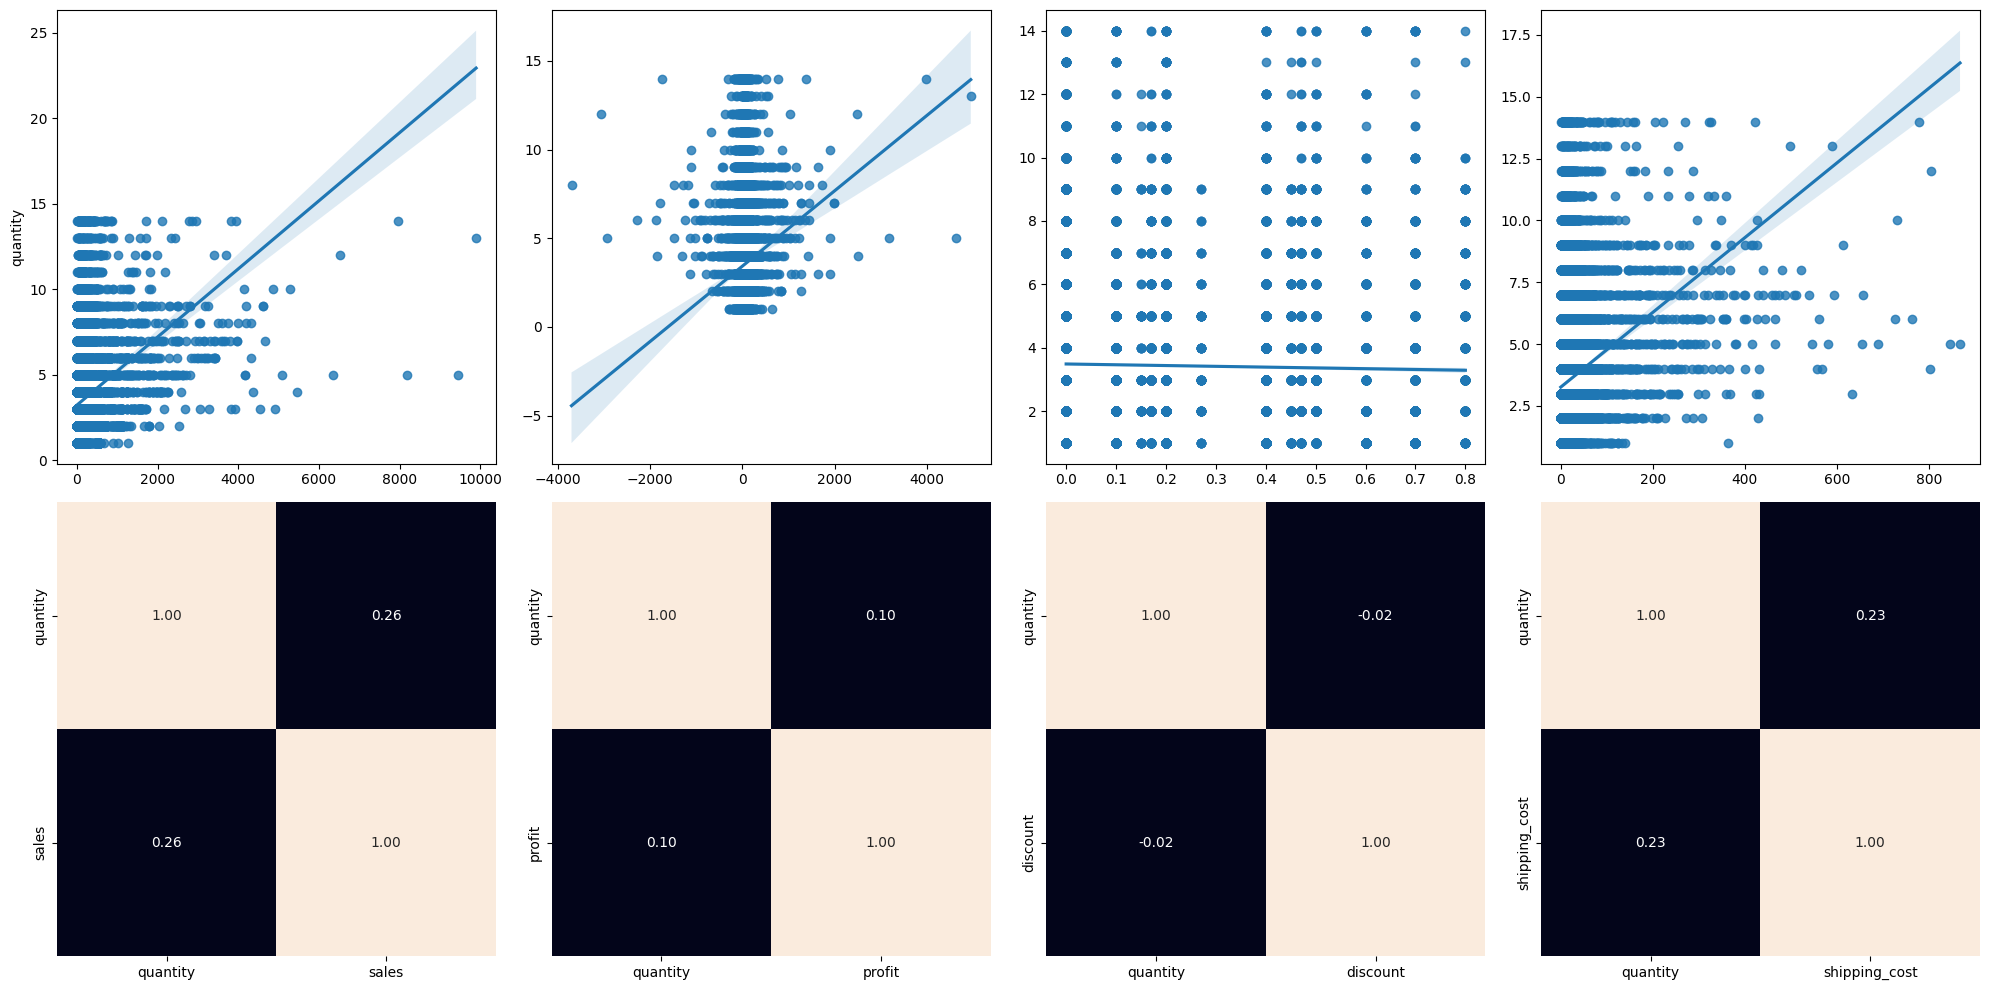

In [16]:
# Numerico - Numerico

fig, ax = plt.subplots(2,4,figsize = (20,10))

sns.regplot(ax = ax[0,0],data=df,x = 'sales', y = 'quantity').set(xlabel = None)
sns.heatmap(df[['quantity','sales']].corr(),annot= True,fmt='.2f',ax=ax[1,0], cbar=False)
sns.regplot(ax = ax[0,1],data=df,x = 'profit', y = 'quantity').set(xlabel = None, ylabel = None)
sns.heatmap(df[['quantity','profit']].corr(),annot= True,fmt='.2f',ax=ax[1,1], cbar=False)
sns.regplot(ax = ax[0,2],data=df,x = 'discount', y = 'quantity').set(xlabel = None, ylabel = None)
sns.heatmap(df[['quantity','discount']].corr(),annot= True,fmt='.2f',ax=ax[1,2], cbar=False)
sns.regplot(ax = ax[0,3],data=df,x = 'shipping_cost', y = 'quantity').set(xlabel = None, ylabel = None)
sns.heatmap(df[['quantity','shipping_cost']].corr(),annot= True,fmt='.2f',ax=ax[1,3], cbar=False)


plt.tight_layout()
plt.show()

In [17]:
# Vectorizado

df['ship_mode'] = pd.factorize(df['ship_mode'])[0]
df['segment'] = pd.factorize(df['segment'])[0]
df['market'] = pd.factorize(df['market'])[0]
df['region'] = pd.factorize(df['region'])[0]
df['category'] = pd.factorize(df['category'])[0]
df['sub-category'] = pd.factorize(df['sub-category'])[0]
df['order_priority'] = pd.factorize(df['order_priority'])[0]


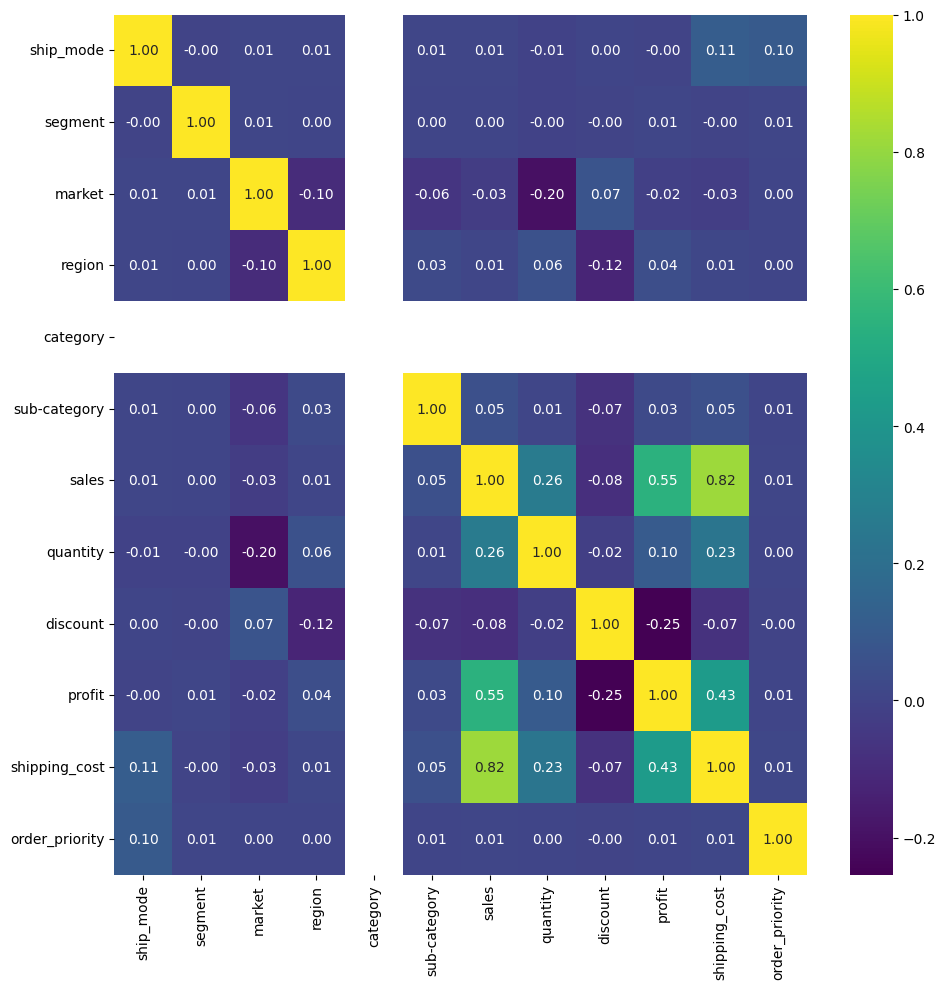

In [18]:
fig, ax = plt.subplots(figsize = (10,10))

sns.heatmap(df.drop('order_month',axis=1).corr(method='pearson'), annot=True,fmt='.2f',cmap='viridis',ax=ax)

plt.tight_layout()
plt.show()

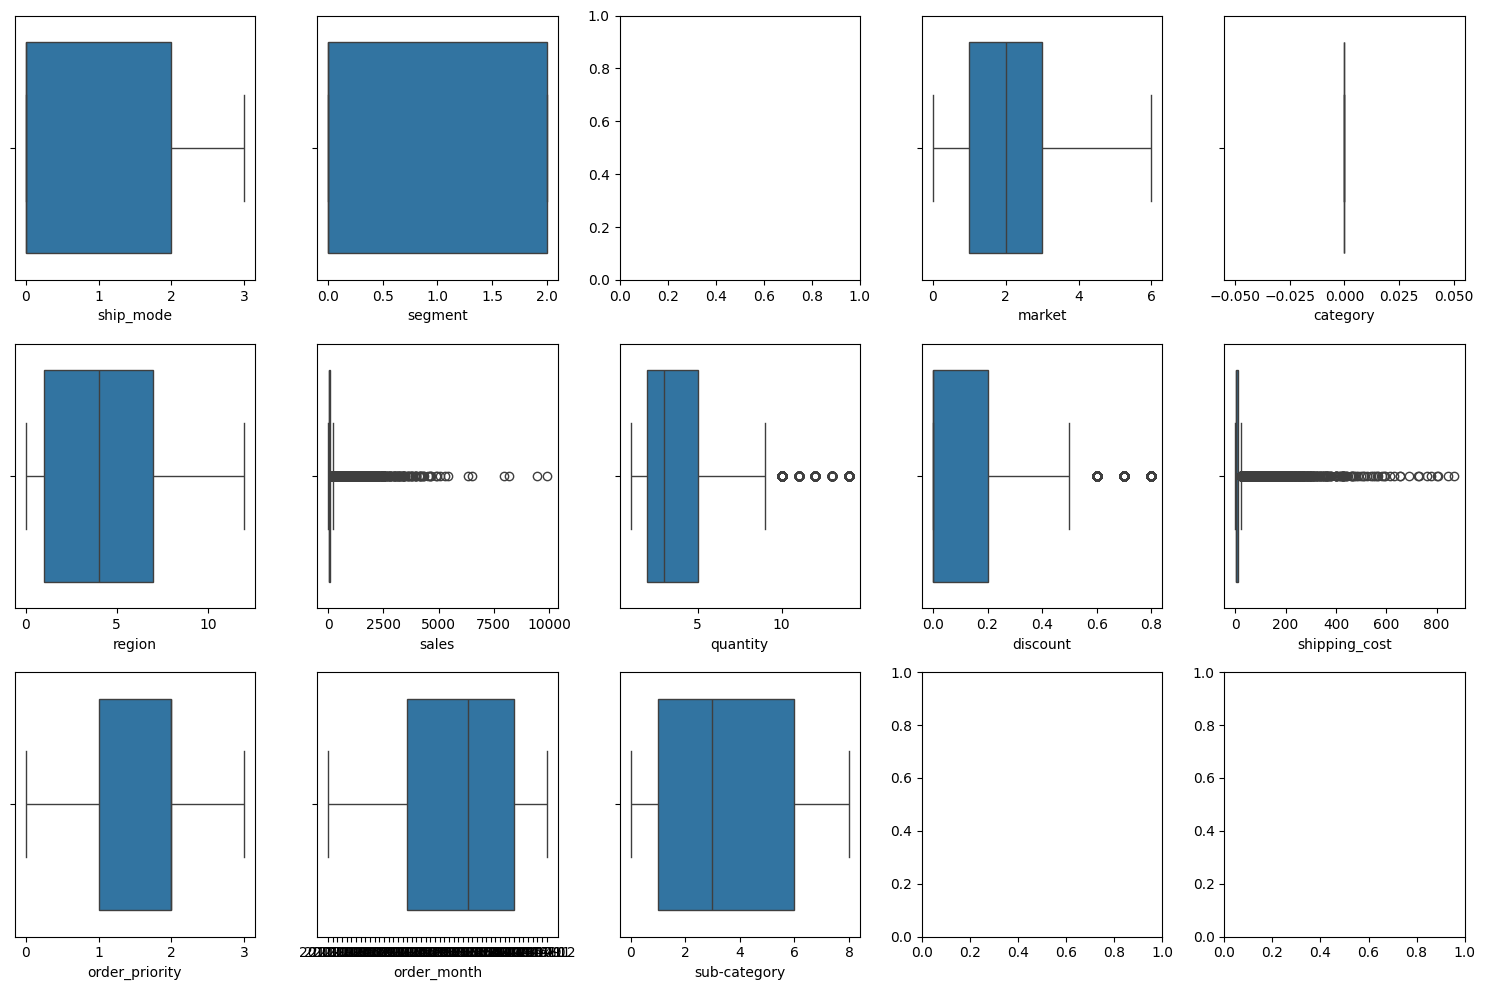

In [19]:
# Analisis de Outliers

fig , ax = plt.subplots(3,5,figsize=(15,10))

sns.boxplot(ax=ax[0,0], data= df, x = 'ship_mode')
sns.boxplot(ax=ax[0,1], data= df, x = 'segment')
sns.boxplot(ax=ax[0,3], data= df, x = 'market')
sns.boxplot(ax=ax[0,4], data= df, x = 'category')
sns.boxplot(ax=ax[1,0], data= df, x = 'region')
sns.boxplot(ax=ax[1,1], data= df, x = 'sales')
sns.boxplot(ax=ax[1,2], data= df, x = 'quantity')
sns.boxplot(ax=ax[1,3], data= df, x = 'discount')
sns.boxplot(ax=ax[1,4], data= df, x = 'shipping_cost')
sns.boxplot(ax=ax[2,0], data= df, x = 'order_priority')
sns.boxplot(ax=ax[2,1], data= df, x = 'order_month')
sns.boxplot(ax=ax[2,2], data= df, x = 'sub-category')

plt.tight_layout()
plt.show()

- La mayoria de los outliers estan muy seguidos, por lo que no parecieran ser outliers. Y los descuentos mas altos son los que podrian generar mayores posibilidades de perdida. por lo que no se quitaran outliers

In [20]:
df = df.drop('sub-category', axis =1)
import pandas as pd

In [22]:
df.head()

,ship_mode,segment,market,region,category,sales,quantity,discount,profit,shipping_cost,order_priority,order_month
30643,0,0,0,0,0,60.9600,8,0.00,28.6400,5.216,0,2011-01
29861,0,1,1,1,0,51.6285,7,0.45,4.5885,5.550,1,2011-01
29871,1,0,0,0,0,47.9600,2,0.00,15.8000,5.546,2,2011-01
16593,0,0,2,0,0,177.6600,7,0.00,58.5900,16.940,2,2011-01
24712,0,0,3,0,0,66.5800,2,0.00,15.9792,8.400,2,2011-01


In [23]:
from sklearn.model_selection import train_test_split

x = df.drop('quantity', axis =1)
y = df['quantity']

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# CORREMOS EL MODELO

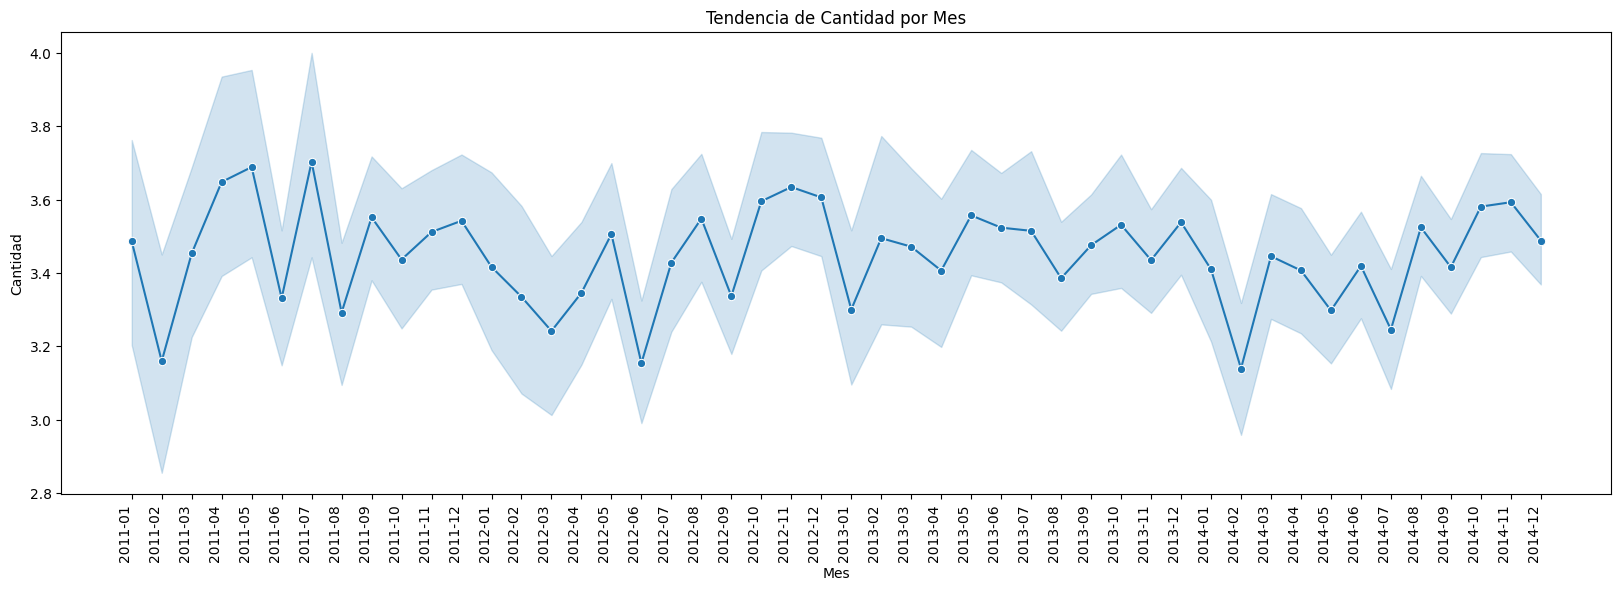

In [27]:
plt.figure(figsize=(20, 6))
sns.lineplot(data=df, x='order_month', y='quantity', marker='o')

# Títulos y etiquetas
plt.title('Tendencia de Cantidad por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.xticks(rotation=90, ha='right')

plt.show()

# Hiperparametrizacion del modelo